# PrimateFace Tutorial: Vocal-Motor Coupling Analysis

| GitHub Repo | Paper | Project Page |
|---|---|---|
| [PrimateFace](https://github.com/KordingLab/PrimateFace) | [PrimateFace](https://www.biorxiv.org/content/10.1101/2025.08.12.669927) | [PrimateFace](https://primateface.studio/) |

This tutorial demonstrates how to analyze the coupling between facial kinematics (mouth aperture) and vocalizations in primates. It uses PrimateFace models to extract facial landmarks and correlates mouth movements with audio spectrograms.

### This notebook will:
1. **Verify the local GPU environment** with all necessary deep learning libraries.
2. **Load pre-trained models** for face detection and 68-point landmark estimation.
3. **Extract facial landmarks** from video frames and align faces to a canonical space.
4. **Compute mouth aperture** time series from inner lip landmarks.
5. **Generate audio spectrogram** and extract the amplitude envelope.
6. **Perform cross-correlation** between mouth aperture and audio envelope.
7. **Train predictive models** (SVR) to predict audio from mouth kinematics.
8. **Visualize results**: time series, cross-correlation, and model performance.

---
### Prerequisites

Before running this notebook, ensure you have:
1. A local NVIDIA GPU with CUDA (recommended; CPU fallback supported but slow)
2. The PrimateFace conda environment activated
3. Downloaded the required model weights (see `demos/download_models.py`)
4. A video with primate vocalizations (ideally with visible mouth movements)

## 1. Environment Setup & Verification

In [1]:
# 1.1 Environment Check
import sys
import warnings
from pathlib import Path

# Add notebooks dir to path for notebook_utils
sys.path.insert(0, str(Path.cwd()))
from notebook_utils import (
    check_environment, get_device, init_models,
    setup_publication_style, save_fig, download_models_hf,
)

env_info = check_environment(require_packages=["mmdet", "mmpose", "librosa"])
DEVICE = get_device()
setup_publication_style()

import torch
import numpy as np
print(f"NumPy: {np.__version__}")
print()
print(f"Using device: {DEVICE}")


PrimateFace Environment
  Python:   3.10.18
  PyTorch:  2.1.0+cu118
  CUDA:     True
  Device:   cuda:0
  GPU:      NVIDIA GeForce RTX 4090 (25.8 GB)
  mmdet: 3.2.0 [OK]
  mmpose: 1.3.2 [OK]
  librosa: 0.11.0 [OK]


Publication plot style configured (Nature-style).
NumPy: 1.26.4

Using device: cuda:0


In [2]:
# 1.2 Import Libraries
import os
import warnings
from pathlib import Path
from typing import List, Dict, Any

import cv2
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
try:
    from moviepy.editor import VideoFileClip  # moviepy v1
except ImportError:
    from moviepy import VideoFileClip  # moviepy v2
from scipy.signal import medfilt, detrend, resample, correlate
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from tqdm.notebook import tqdm

# MMDetection and MMPose imports
from mmdet.apis import inference_detector, init_detector
from mmpose.apis import inference_topdown, init_model as init_pose_estimator
from mmpose.utils import adapt_mmdet_pipeline

# Suppress noisy warnings
warnings.filterwarnings("ignore", category=UserWarning, module="librosa")
warnings.filterwarnings("ignore", category=FutureWarning)

# Set random seed for reproducibility
np.random.seed(42)

%matplotlib inline
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configuration

Configure paths to models, input video, and output directory.

In [3]:
# 2.1 Path Configuration
NOTEBOOK_DIR = Path.cwd()
DEMOS_DIR = NOTEBOOK_DIR.parent  # demos/

# Download models from HuggingFace (skips if already present)
print("Downloading/checking model files...")
model_paths = download_models_hf(DEMOS_DIR)

DET_CONFIG_PATH = model_paths["mmdet_config.py"]
DET_CHECKPOINT_PATH = model_paths["mmdet_checkpoint.pth"]
POSE_CONFIG_PATH = model_paths["mmpose_config.py"]
POSE_CHECKPOINT_PATH = model_paths["mmpose_checkpoint.pth"]

# Use device detected in cell 1.1
DEFAULT_DEVICE = DEVICE
print()
print(f"Device: {DEFAULT_DEVICE}")


Downloading/checking model files...
  Already exists: mmdet_config.py (0.0 MB)
  Already exists: mmdet_checkpoint.pth (339.8 MB)
  Already exists: mmpose_config.py (0.0 MB)
  Already exists: mmpose_checkpoint.pth (37.8 MB)
  Already exists: vitpose_config.py (0.0 MB)
  Already exists: vitpose_checkpoint.pth (1192.4 MB)

Device: cuda:0


In [4]:
# 2.2 Video and Output Configuration

# Input video path - UPDATE THIS to your howler/vocalization video
VIDEO_PATH = Path(r"A:\NonEnclosureProjects\inprep\PrimateFace\data\Howler Monkey Call #shorts #short.mp4")

# Alternative: specify your own video path
# VIDEO_PATH = Path("/path/to/your/primate_vocalization_video.mp4")

# Output directory for results
OUTPUT_DIR = Path("./vocal_motor_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Video path: {VIDEO_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

if not VIDEO_PATH.exists():
    print(f"\nWARNING: Video not found at {VIDEO_PATH}")
    print("Please update VIDEO_PATH to point to your primate vocalization video.")

Video path: A:\NonEnclosureProjects\inprep\PrimateFace\data\Howler Monkey Call #shorts #short.mp4
Output directory: vocal_motor_output


In [5]:
# 2.3 Analysis Parameters

# Audio processing
AUDIO_SR = 22050  # Sample rate for audio
N_FFT = 1024      # FFT window size for spectrogram

# Frequency filtering for envelope (optional, set to None to use full spectrum)
MIN_FREQ = None   # e.g., 100 Hz to filter out low-frequency rumble
MAX_FREQ = None   # e.g., 8000 Hz to focus on vocalization frequencies

# Mouth aperture processing
MOUTH_FILTER_WINDOW = 5  # Median filter window (odd number)

# Cross-correlation
MAX_CORR_MS = 500  # Max lag for cross-correlation (±500ms)

# Predictive model
MODEL_LAG_MS = 500  # Lag range for SVR features (±500ms)
MODEL_STEP_MS = 50  # Step size for lag features

# Processing limit (set to None to process full video)
PROCESSING_DURATION_SEC = 5.0  # Process first 5 seconds for demo  # e.g., 10.0 to process only first 10 seconds

print("Analysis parameters configured.")

Analysis parameters configured.


## 3. Helper Functions

This section contains all core functions for video/audio processing, landmark extraction, and analysis.

In [6]:
# 3.1 Constants for Landmark Processing

# Face alignment constants imported from PrimateFace API
import sys
sys.path.insert(0, str(Path('..').resolve()))
from constants import LANDMARK_5PT_FROM_68_INDICES, TARGET_LANDMARKS_5PT_256X256, ALIGNED_FACE_SIZE
from process import get_5_source_landmarks_from_68, align_face, transform_keypoints

LANDMARK_INDICES_68PT_FOR_5PT_ALIGNMENT = LANDMARK_5PT_FROM_68_INDICES

print("Constants defined (imported from PrimateFace API).")


Constants defined (imported from PrimateFace API).


In [7]:
# 3.2 Video & Audio I/O Functions

def load_video_and_audio(video_path: str, audio_sr: int = 22050, max_duration_sec: float = None):
    """Load video clip and extract audio.
    
    Returns:
        clip: MoviePy VideoFileClip object
        audio: Mono audio array
        sr: Audio sample rate
        fps: Video frame rate
        t_vid: Video time axis
        t_aud: Audio time axis
    """
    if not os.path.isfile(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")

    print(f"Loading video: {video_path}")
    full_clip = VideoFileClip(video_path)
    fps = full_clip.fps
    original_duration = full_clip.duration

    # Apply duration limit if specified
    effective_duration = original_duration
    if max_duration_sec is not None and max_duration_sec > 0:
        if max_duration_sec < original_duration:
            effective_duration = max_duration_sec
            print(f"  Truncating to first {effective_duration:.2f} seconds")
            clip = full_clip.subclipped(0, effective_duration)
        else:
            clip = full_clip
    else:
        clip = full_clip

    print(f"  Extracting audio (resampling to {audio_sr} Hz)...")
    audio_frames = clip.audio.to_soundarray(fps=audio_sr)
    audio = audio_frames.mean(axis=1) if audio_frames.ndim == 2 else audio_frames.flatten()
    
    num_video_frames = int(clip.duration * fps)
    t_vid = np.arange(num_video_frames) / fps
    t_aud = np.arange(len(audio)) / audio_sr
    
    print(f"  Duration: {clip.duration:.2f}s, Frames: {num_video_frames}, Audio samples: {len(audio)}")

    return clip, audio.astype(np.float32), audio_sr, fps, t_vid, t_aud


print("Video/Audio I/O functions defined.")

Video/Audio I/O functions defined.


In [8]:
# 3.3 Landmark Extraction
# init_models() is imported from notebook_utils (cell 1.1)

def extract_landmarks(frame_bgr: np.ndarray, detector, pose_model, bbox_thr: float = 0.5):
    """Detect primate face and extract all facial landmarks."""
    det_result = inference_detector(detector, frame_bgr)
    pred_instances = det_result.pred_instances[det_result.pred_instances.scores > bbox_thr]
    
    if len(pred_instances) == 0:
        return None
    
    target_bbox = pred_instances.bboxes[:1].cpu().numpy()
    pose_res = inference_topdown(pose_model, frame_bgr, target_bbox)
    
    if not pose_res or not hasattr(pose_res[0], 'pred_instances'):
        return None
    if len(pose_res[0].pred_instances.keypoints) == 0:
        return None
    
    kpts = pose_res[0].pred_instances.keypoints[0]
    return kpts.cpu().numpy() if hasattr(kpts, "cpu") else np.array(kpts)


print("Landmark extraction function defined.")

Landmark extraction function defined.


In [9]:
# 3.4 Landmark Caching Function

def cache_landmarks(clip: VideoFileClip, detector, pose_model, cache_fp: str, max_frames: int = None):
    """Extract landmarks from all video frames with alignment."""
    print(f"\nCache file path: {cache_fp}")
    
    # Check for existing cache
    if os.path.exists(cache_fp):
        try:
            loaded = np.load(cache_fp)
            if "landmarks" in loaded and "valid" in loaded and "transforms" in loaded:
                print(f"Loaded landmarks from cache ({loaded['landmarks'].shape[0]} frames)")
                return (loaded["landmarks"].astype(np.float32), 
                        loaded["valid"].astype(bool), 
                        loaded["transforms"].astype(np.float32))
        except Exception as e:
            print(f"Could not load cache: {e}. Re-processing.")

    # Process frames
    n_total_frames = int(clip.duration * clip.fps)
    frames_to_process = min(n_total_frames, max_frames) if max_frames else n_total_frames
    
    if frames_to_process == 0:
        return (np.empty((0, 68, 2), dtype=np.float32), 
                np.empty(0, dtype=bool), 
                np.empty((0, 2, 3), dtype=np.float32))

    n_kpts = 68
    all_kpts = np.full((frames_to_process, n_kpts, 2), np.nan, dtype=np.float32)
    valid_mask = np.zeros(frames_to_process, dtype=bool)
    all_transforms = np.full((frames_to_process, 2, 3), np.nan, dtype=np.float32)

    print(f"Extracting landmarks from {frames_to_process} frames...")
    
    for fi, frame_pil in enumerate(tqdm(clip.iter_frames(), total=frames_to_process, desc="Landmark Extraction")):
        if fi >= frames_to_process:
            break
            
        frame_bgr = cv2.cvtColor(np.array(frame_pil), cv2.COLOR_RGB2BGR)
        raw_kpts = extract_landmarks(frame_bgr, detector, pose_model)
        
        if raw_kpts is not None and raw_kpts.shape[0] == n_kpts:
            source_5pts = get_5_source_landmarks_from_68(raw_kpts)
            
            if not np.any(np.isnan(source_5pts)):
                transform_matrix, _ = cv2.estimateAffinePartial2D(
                    source_5pts, TARGET_LANDMARKS_5PT_256X256, method=cv2.LMEDS
                )
                
                if transform_matrix is None:
                    transform_matrix, _ = cv2.estimateAffine2D(source_5pts, TARGET_LANDMARKS_5PT_256X256)
                
                if transform_matrix is not None:
                    aligned_kpts = transform_keypoints(raw_kpts, transform_matrix)
                    all_kpts[fi] = aligned_kpts
                    all_transforms[fi] = transform_matrix
                    valid_mask[fi] = True

    # Save cache
    os.makedirs(os.path.dirname(cache_fp), exist_ok=True)
    np.savez_compressed(cache_fp, landmarks=all_kpts, valid=valid_mask, transforms=all_transforms)
    print(f"Cached landmarks to {cache_fp}")
    print(f"  Valid frames: {valid_mask.sum()} / {frames_to_process}")
    
    return all_kpts, valid_mask, all_transforms


print("Landmark caching function defined.")

Landmark caching function defined.


In [10]:
# 3.5 Mouth Aperture via extract_timeseries()

# Import the analysis module (repo root is two levels up from notebooks/)
import sys
_repo_root = str(Path('../..').resolve())
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)
from primateface.analysis.kinematics import extract_timeseries

print("extract_timeseries imported from primateface.analysis.kinematics.")


extract_timeseries imported from primateface.analysis.kinematics.


In [11]:
# 3.6 Spectrogram & Envelope Functions

def spectrogram_env(audio: np.ndarray, sr: int, fps: float, n_fft: int = 1024,
                    min_freq: float = None, max_freq: float = None):
    """Generate spectrogram and extract normalized envelope.
    
    Returns:
        S_db: Log-magnitude spectrogram
        envelope_normalized: Normalized amplitude envelope
        t_spec: Time axis for spectrogram
        hop_length: Hop length used
    """
    hop_length = int(sr / fps)
    if hop_length == 0:
        raise ValueError("hop_length is 0. Check sr and fps values.")

    # Ensure n_fft is power of 2 and >= hop_length
    if n_fft < hop_length:
        n_fft = 2**int(np.ceil(np.log2(hop_length)))
    elif 2**int(np.log2(n_fft)) != n_fft:
        n_fft = 2**int(np.ceil(np.log2(n_fft)))

    S_complex = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    S_abs = np.abs(S_complex)
    S_abs_for_env = S_abs.copy()

    # Apply frequency filtering if specified
    if min_freq is not None or max_freq is not None:
        freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
        freq_mask = np.ones(len(freqs), dtype=bool)
        if min_freq is not None:
            freq_mask &= (freqs >= min_freq)
        if max_freq is not None:
            freq_mask &= (freqs <= max_freq)
        
        if np.sum(freq_mask) > 0:
            S_abs_for_env = S_abs[freq_mask, :]

    S_db = librosa.amplitude_to_db(S_abs, ref=np.max(S_abs))
    
    envelope_raw = np.max(S_abs_for_env, axis=0)
    envelope_normalized = librosa.util.normalize(envelope_raw)
    
    t_spec = librosa.times_like(S_db, sr=sr, hop_length=hop_length)
    
    return S_db, envelope_normalized.astype(np.float32), t_spec, hop_length


def align_signals(signal_a: np.ndarray, signal_b: np.ndarray):
    """Resample signal_b to match length of signal_a."""
    if len(signal_a) == len(signal_b):
        return signal_a, signal_b
    if len(signal_b) == 0 or len(signal_a) == 0:
        return signal_a, signal_b
    
    signal_b_resampled = resample(signal_b, len(signal_a))
    return signal_a, signal_b_resampled


print("Spectrogram and envelope functions defined.")

Spectrogram and envelope functions defined.


In [12]:
# 3.7 Cross-Correlation & Model Training Functions

def cross_correlation(signal1: np.ndarray, signal2: np.ndarray, max_lag_frames: int):
    """Calculate cross-correlation between two signals."""
    if len(signal1) == 0 or len(signal2) == 0 or len(signal1) != len(signal2):
        return np.array([]), np.array([])

    # Normalize signals
    sig1_norm = (signal1 - np.mean(signal1)) / (np.std(signal1) + 1e-9)
    sig2_norm = (signal2 - np.mean(signal2)) / (np.std(signal2) + 1e-9)

    correlation_full = correlate(sig1_norm, sig2_norm, mode='full', method='auto')
    
    center_idx = len(correlation_full) // 2
    effective_max_lag = min(max_lag_frames, center_idx)

    selected_correlations = correlation_full[center_idx - effective_max_lag : center_idx + effective_max_lag + 1]
    lags = np.arange(-effective_max_lag, effective_max_lag + 1)
    
    # Normalize to Pearson r
    selected_correlations = selected_correlations / len(signal1)

    return lags, selected_correlations


def train_svr_model(mouth_signal: np.ndarray, env_signal: np.ndarray, 
                    model_lags_ms: np.ndarray, fps: float, n_splits: int = 5):
    """Train SVR model to predict audio envelope from mouth aperture."""
    if len(mouth_signal) == 0 or len(env_signal) == 0 or len(mouth_signal) != len(env_signal):
        return np.array([]), None

    lag_frames = sorted(list(set([int(lag * fps / 1000.0) for lag in model_lags_ms])))

    # Calculate valid index range
    start_idx = max(0, -min(lag_f for lag_f in lag_frames if lag_f < 0) if any(lag_f < 0 for lag_f in lag_frames) else 0)
    end_idx = len(mouth_signal) - (max(lag_f for lag_f in lag_frames if lag_f > 0) if any(lag_f > 0 for lag_f in lag_frames) else 0)

    if start_idx >= end_idx or (end_idx - start_idx) < max(n_splits, len(lag_frames)):
        print(f"Error: Not enough data for SVR (effective length: {end_idx - start_idx})")
        return np.array([]), None

    y = env_signal[start_idx:end_idx]
    X_list = [mouth_signal[(start_idx - lag_f):(end_idx - lag_f)] for lag_f in lag_frames]
    X = np.stack(X_list, axis=1)

    # Pipeline with scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ])

    param_grid = {
        'svr__kernel': ['rbf'],
        'svr__C': [0.1, 1, 10],
        'svr__gamma': ['scale', 'auto', 0.1],
    }

    cv_fold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    print(f"Training SVR with GridSearchCV...")
    grid_search = GridSearchCV(pipeline, param_grid, cv=cv_fold, scoring='r2', n_jobs=-1, verbose=0)
    
    try:
        grid_search.fit(X, y)
    except ValueError as e:
        print(f"Error during SVR training: {e}")
        return np.array([]), None

    print(f"  Best parameters: {grid_search.best_params_}")
    print(f"  Best R^2: {grid_search.best_score_:.3f}")
    
    # Extract per-fold scores
    r2_scores = [grid_search.cv_results_[f'split{i}_test_score'][grid_search.best_index_] 
                 for i in range(n_splits)]
    
    return np.array(r2_scores), grid_search.best_estimator_


print("Cross-correlation and model training functions defined.")

Cross-correlation and model training functions defined.


In [13]:
# 3.8 Visualization Functions

def plot_signals_and_spectrogram(t_aligned, mouth_aligned, env_aligned, S_db, t_spec, sr, hop_length, output_path=None):
    """Plot mouth aperture, envelope, and spectrogram."""
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(7, 5), gridspec_kw={'height_ratios': [1, 1, 2]})
    
    # Mouth aperture
    axes[0].plot(t_aligned, mouth_aligned, color='blue', label='Mouth Aperture')
    axes[0].set_ylabel('Z-score')
    axes[0].set_title('Processed Mouth Aperture', fontsize=12)
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle=':', alpha=0.7)

    # Envelope
    axes[1].plot(t_aligned, env_aligned, color='green', label='Audio Envelope')
    axes[1].set_ylabel('Normalized Amplitude')
    axes[1].set_title('Spectrogram Envelope', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle=':', alpha=0.7)
    
    # Spectrogram
    common_time = t_aligned[-1] if len(t_aligned) > 0 else t_spec[-1]
    display_idx = np.where(t_spec <= common_time)[0]
    S_db_display = S_db[:, display_idx] if len(display_idx) > 0 else S_db
    t_spec_display = t_spec[display_idx] if len(display_idx) > 0 else t_spec
    
    img = librosa.display.specshow(S_db_display, sr=sr, hop_length=hop_length, 
                                   x_axis='time', y_axis='log', ax=axes[2], 
                                   x_coords=t_spec_display)
    axes[2].set_title('Log-Magnitude Spectrogram', fontsize=12)
    axes[2].set_xlabel('Time (s)')
    fig.colorbar(img, ax=axes[2], format='%+2.0f dB')
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.savefig(Path(output_path).with_suffix('.svg'), bbox_inches='tight')
        print(f"Saved signals plot to {output_path}")
    plt.show()
    plt.close(fig)


def plot_cross_correlation(lags_frames, correlations, fps, output_path=None):
    """Plot cross-correlation results."""
    if len(lags_frames) == 0 or np.all(np.isnan(correlations)):
        print("Skipping cross-correlation plot (no valid data).")
        return

    lags_ms = lags_frames * (1000.0 / fps)
    
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(lags_ms, correlations, marker='.', markersize=4)
    
    peak_idx = np.nanargmax(correlations)
    peak_lag_ms = lags_ms[peak_idx]
    peak_corr = correlations[peak_idx]
    ax.axvline(peak_lag_ms, color='r', linestyle='--', 
               label=f'Peak: {peak_lag_ms:.1f} ms (r={peak_corr:.2f})')
    
    ax.set_xlabel('Lag (ms) [Positive: Mouth leads Audio]', fontsize=11)
    ax.set_ylabel('Cross-correlation (r)', fontsize=11)
    ax.set_title('Cross-correlation: Mouth Aperture vs. Audio Envelope', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.savefig(Path(output_path).with_suffix('.svg'), bbox_inches='tight')
        print(f"Saved cross-correlation plot to {output_path}")
    plt.show()
    plt.close(fig)


def plot_model_performance(results: List[Dict[str, Any]], output_path=None):
    """Plot R^2 scores as bar chart."""
    if not results:
        print("No model results to plot.")
        return

    model_names = [res['name'] for res in results]
    mean_r2s = [np.mean(res['r2_scores']) if res['r2_scores'].size > 0 else np.nan for res in results]
    std_r2s = [np.std(res['r2_scores']) if res['r2_scores'].size > 0 else np.nan for res in results]

    x_pos = np.arange(len(model_names))
    colors = ['lightcoral' if 'Shuffled' in name else 'skyblue' for name in model_names]
    
    fig, ax = plt.subplots(figsize=(5, 3.5))
    bars = ax.bar(x_pos, mean_r2s, yerr=std_r2s, capsize=5, color=colors, ecolor='gray')

    ax.set_ylabel('R\u00b2 Score', fontsize=11)
    ax.set_title('Predictive Model Performance (5-fold CV)', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    
    # Add values on bars
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        if not np.isnan(yval):
            ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, 
                    f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.7, label='Chance (R\u00b2=0)')
    ax.set_ylim(min(-0.1, min(mean_r2s) - 0.1), max(0.5, max(mean_r2s) + 0.15))
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.savefig(Path(output_path).with_suffix('.svg'), bbox_inches='tight')
        print(f"Saved model performance plot to {output_path}")
    plt.show()
    plt.close(fig)


print("Visualization functions defined.")

Visualization functions defined.


## 4. Run Analysis Pipeline

Execute the complete vocal-motor coupling analysis.


STARTING VOCAL-MOTOR COUPLING ANALYSIS

[Step 1/6] Loading video and audio...
Loading video: A:\NonEnclosureProjects\inprep\PrimateFace\data\Howler Monkey Call #shorts #short.mp4


  Truncating to first 5.00 seconds
  Extracting audio (resampling to 22050 Hz)...
  Duration: 5.00s, Frames: 149, Audio samples: 110250

[Step 2/6] Extracting facial landmarks...
Loading MMDetection model...


Loads checkpoint by local backend from path: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os-bench\demos\mmdet_checkpoint.pth


Loading MMPose model...
Loads checkpoint by local backend from path: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os-bench\demos\mmpose_checkpoint.pth



Cache file path: vocal_motor_output\Howler Monkey Call #shorts #short_landmarks.npz
Extracting landmarks from 149 frames...


Landmark Extraction:   0%|          | 0/149 [00:00<?, ?it/s]

Cached landmarks to vocal_motor_output\Howler Monkey Call #shorts #short_landmarks.npz
  Valid frames: 140 / 149

[Step 3/6] Calculating mouth aperture...
  Mouth aperture signal length: 140

[Step 4/6] Generating audio spectrogram...


  Envelope length: 151

  Aligning signals...
  Aligned length: 140


Saved signals plot to vocal_motor_output\Howler Monkey Call #shorts #short_signals.png


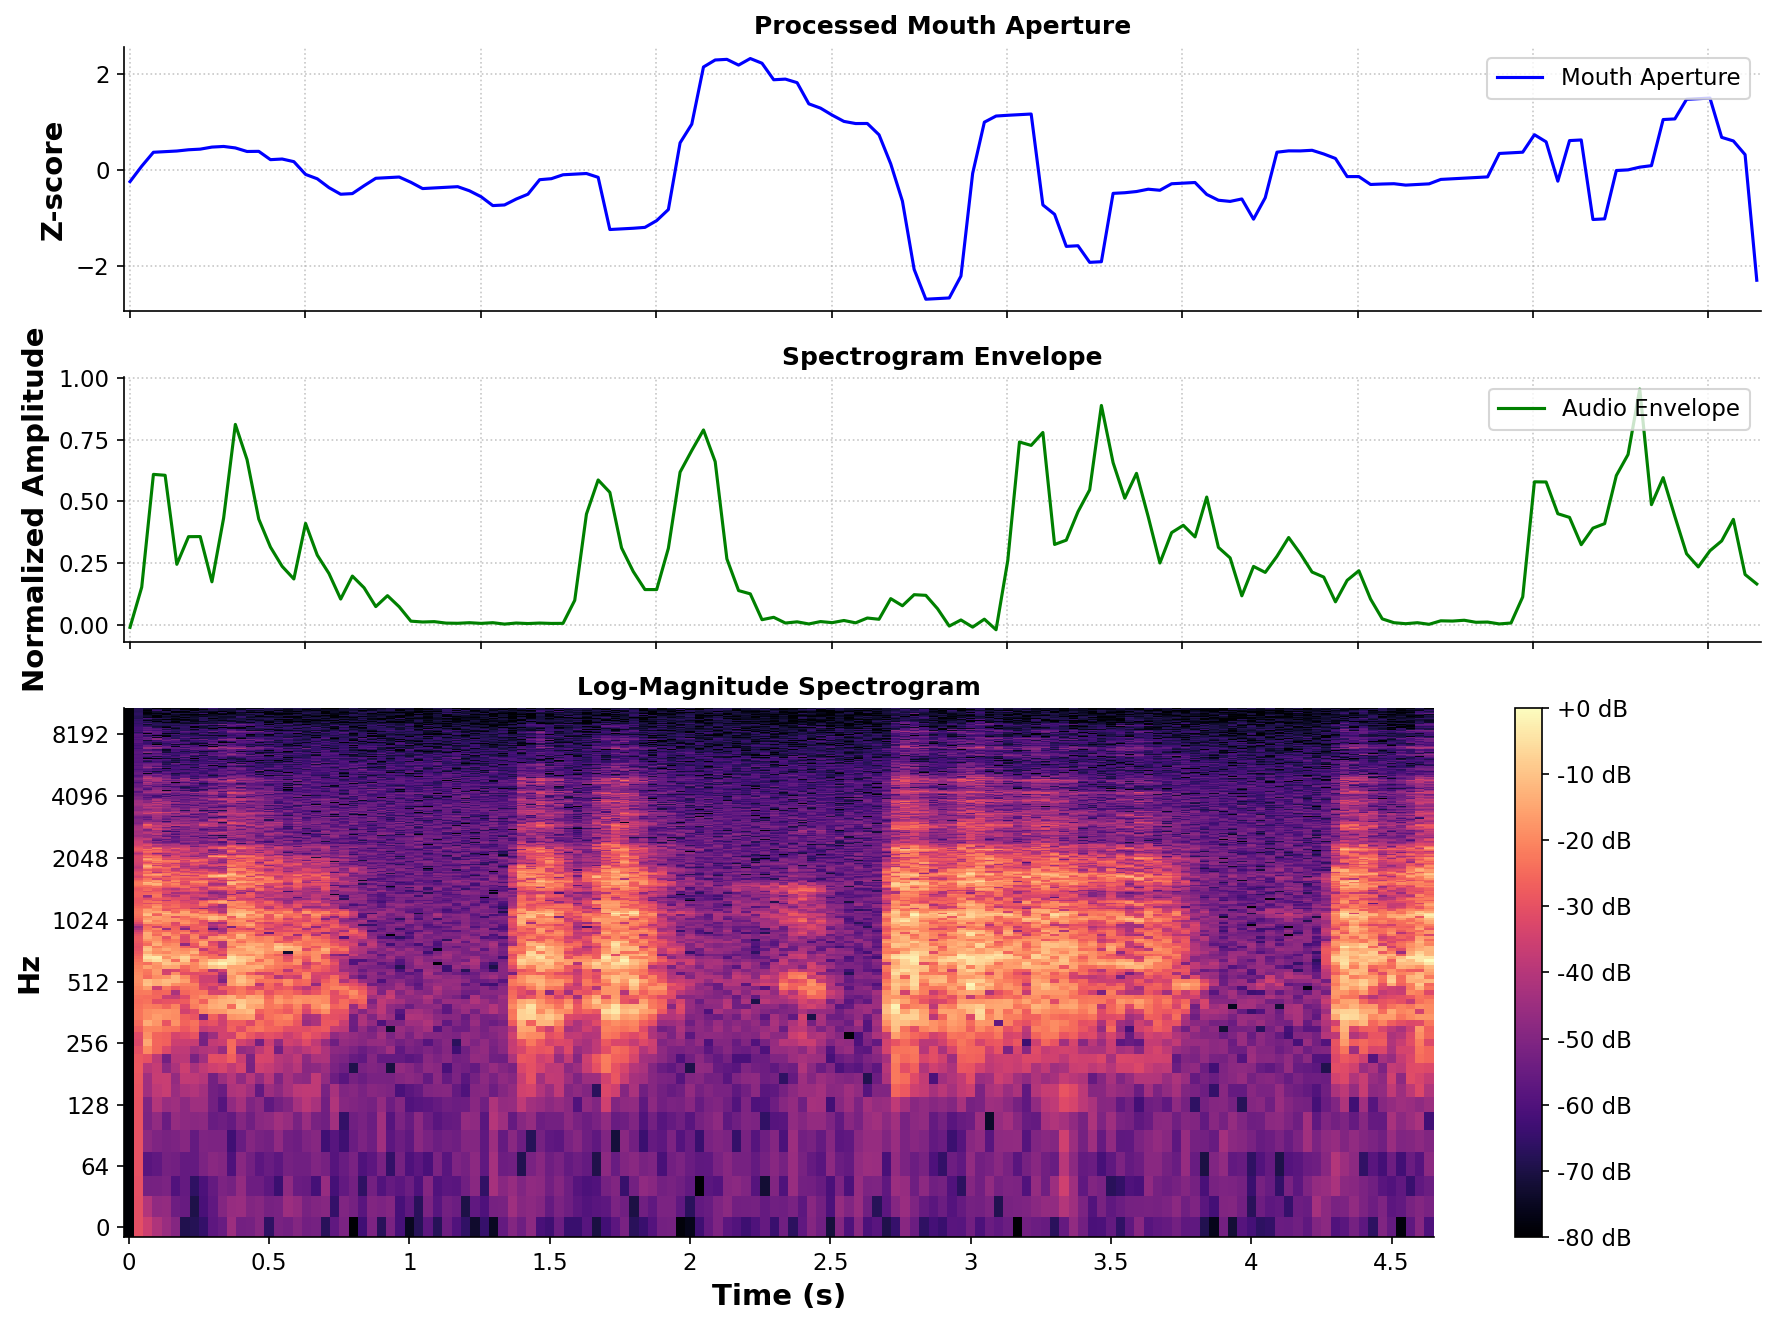


[Step 5/6] Computing cross-correlation...
  Peak correlation at: 300.3 ms (r=0.266)


Saved cross-correlation plot to vocal_motor_output\Howler Monkey Call #shorts #short_xcorr.png


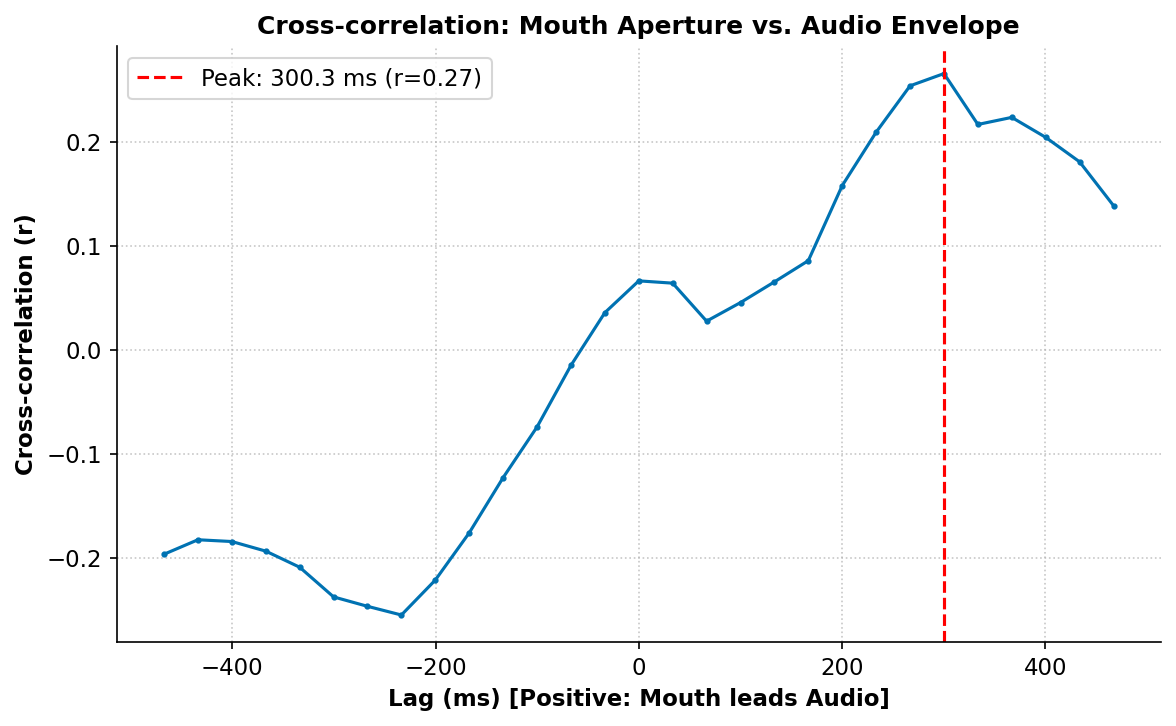


[Step 6/6] Training predictive models...

  Training on original data...
Training SVR with GridSearchCV...


  Best parameters: {'svr__C': 10, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
  Best R^2: 0.579

  Training on shuffled control...
Training SVR with GridSearchCV...
  Best parameters: {'svr__C': 0.1, 'svr__gamma': 0.1, 'svr__kernel': 'rbf'}
  Best R^2: -0.285


Saved model performance plot to vocal_motor_output\Howler Monkey Call #shorts #short_model_performance.png


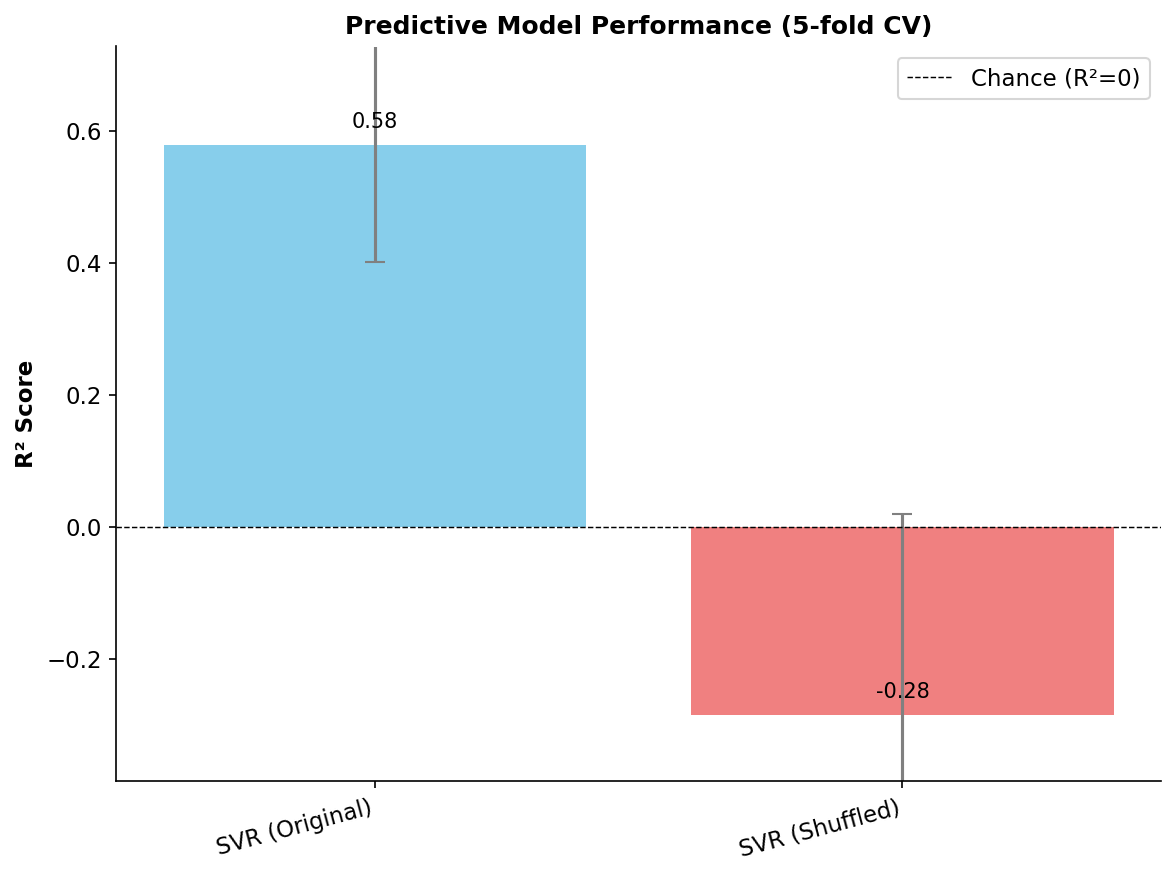


ANALYSIS COMPLETE

Results saved to: vocal_motor_output


In [14]:
# 4.1 Run Analysis

if not VIDEO_PATH.exists():
    print(f"ERROR: Video not found at {VIDEO_PATH}")
    print("Please update VIDEO_PATH in cell 2.2 to point to your video.")
else:
    print("\n" + "="*60)
    print("STARTING VOCAL-MOTOR COUPLING ANALYSIS")
    print("="*60 + "\n")
    
    # Output paths
    video_name = VIDEO_PATH.stem
    output_base = OUTPUT_DIR / video_name
    landmark_cache = OUTPUT_DIR / f"{video_name}_landmarks.npz"

    # Step 1: Load video and audio
    print("[Step 1/6] Loading video and audio...")
    clip, audio, sr, fps, t_vid, t_aud = load_video_and_audio(
        str(VIDEO_PATH), 
        audio_sr=AUDIO_SR,
        max_duration_sec=PROCESSING_DURATION_SEC
    )

    # Step 2: Initialize models and extract landmarks
    print("\n[Step 2/6] Extracting facial landmarks...")
    detector, pose_model = init_models(
        str(DET_CONFIG_PATH), str(DET_CHECKPOINT_PATH),
        str(POSE_CONFIG_PATH), str(POSE_CHECKPOINT_PATH),
        device=DEFAULT_DEVICE
    )
    
    all_landmarks, valid_mask, all_transforms = cache_landmarks(
        clip, detector, pose_model, str(landmark_cache)
    )
    
    if valid_mask.sum() == 0:
        print("\nERROR: No faces detected. Analysis cannot proceed.")
    else:
        # Step 3: Calculate mouth aperture
        print("\n[Step 3/6] Calculating mouth aperture...")
        # Extract per-frame kinematics using the analysis module
        # (uses landmark pair 62-66 for mouth aperture, normalized by IOD)
        valid_landmarks = all_landmarks[valid_mask]
        df_kin = extract_timeseries(valid_landmarks, fps=fps)
        raw_aperture = df_kin["mouth_aperture"].values
        t_mouth = df_kin["time_s"].values.astype(np.float32)

        # Signal processing: median filter -> detrend -> z-score
        _fw = MOUTH_FILTER_WINDOW if MOUTH_FILTER_WINDOW % 2 == 1 else MOUTH_FILTER_WINDOW + 1
        mouth_ap = medfilt(raw_aperture, kernel_size=_fw)
        mouth_ap = detrend(mouth_ap)
        std_ap = np.std(mouth_ap)
        if std_ap > 1e-9:
            mouth_signal = ((mouth_ap - np.mean(mouth_ap)) / std_ap).astype(np.float32)
        else:
            mouth_signal = (mouth_ap - np.mean(mouth_ap)).astype(np.float32)
        print(f"  Mouth aperture signal length: {len(mouth_signal)}")

        # Step 4: Generate spectrogram and envelope
        print("\n[Step 4/6] Generating audio spectrogram...")
        S_db, envelope, t_spec, hop_length = spectrogram_env(
            audio, sr, fps, N_FFT, MIN_FREQ, MAX_FREQ
        )
        print(f"  Envelope length: {len(envelope)}")

        # Align signals
        print("\n  Aligning signals...")
        mouth_aligned, env_aligned = align_signals(mouth_signal, envelope)
        t_aligned = t_mouth
        print(f"  Aligned length: {len(mouth_aligned)}")

        if len(mouth_aligned) == 0 or len(env_aligned) == 0:
            print("\nERROR: Signals empty after alignment.")
        else:
            # Plot signals
            plot_signals_and_spectrogram(
                t_aligned, mouth_aligned, env_aligned, S_db, t_spec, sr, hop_length,
                output_path=str(output_base) + "_signals.png"
            )

            # Step 5: Cross-correlation
            print("\n[Step 5/6] Computing cross-correlation...")
            max_lag_frames = int(MAX_CORR_MS * fps / 1000.0)
            lags_frames, correlations = cross_correlation(mouth_aligned, env_aligned, max_lag_frames)
            
            if len(correlations) > 0:
                peak_idx = np.nanargmax(correlations)
                peak_lag_ms = lags_frames[peak_idx] * (1000.0 / fps)
                print(f"  Peak correlation at: {peak_lag_ms:.1f} ms (r={correlations[peak_idx]:.3f})")
                
                plot_cross_correlation(
                    lags_frames, correlations, fps,
                    output_path=str(output_base) + "_xcorr.png"
                )

            # Step 6: Predictive models
            print("\n[Step 6/6] Training predictive models...")
            model_lags_ms = np.arange(-MODEL_LAG_MS, MODEL_LAG_MS + MODEL_STEP_MS, MODEL_STEP_MS)
            all_results = []

            # Original data
            print("\n  Training on original data...")
            r2_original, _ = train_svr_model(mouth_aligned, env_aligned, model_lags_ms, fps)
            if r2_original.size > 0:
                all_results.append({'name': 'SVR (Original)', 'r2_scores': r2_original})

            # Shuffled control
            print("\n  Training on shuffled control...")
            env_shuffled = np.random.permutation(env_aligned)
            r2_shuffled, _ = train_svr_model(mouth_aligned, env_shuffled, model_lags_ms, fps)
            if r2_shuffled.size > 0:
                all_results.append({'name': 'SVR (Shuffled)', 'r2_scores': r2_shuffled})

            if all_results:
                plot_model_performance(
                    all_results,
                    output_path=str(output_base) + "_model_performance.png"
                )

            print("\n" + "="*60)
            print("ANALYSIS COMPLETE")
            print("="*60)
            print(f"\nResults saved to: {OUTPUT_DIR}")

## 5. Frame Diagnostics

Visual validation of the landmark extraction pipeline. For selected frames, we show:
1. **Raw frame** - original video frame
2. **Detection** - face bounding box overlay
3. **Aligned face** - warped to 256x256 canonical space using 5-point alignment

This helps verify that face detection and alignment are working correctly.

Generating frame diagnostics...
Selected diagnostic frames: [0, 70, 109]


Saved frame diagnostics to vocal_motor_output\Howler Monkey Call #shorts #short_frame_diagnostics.png


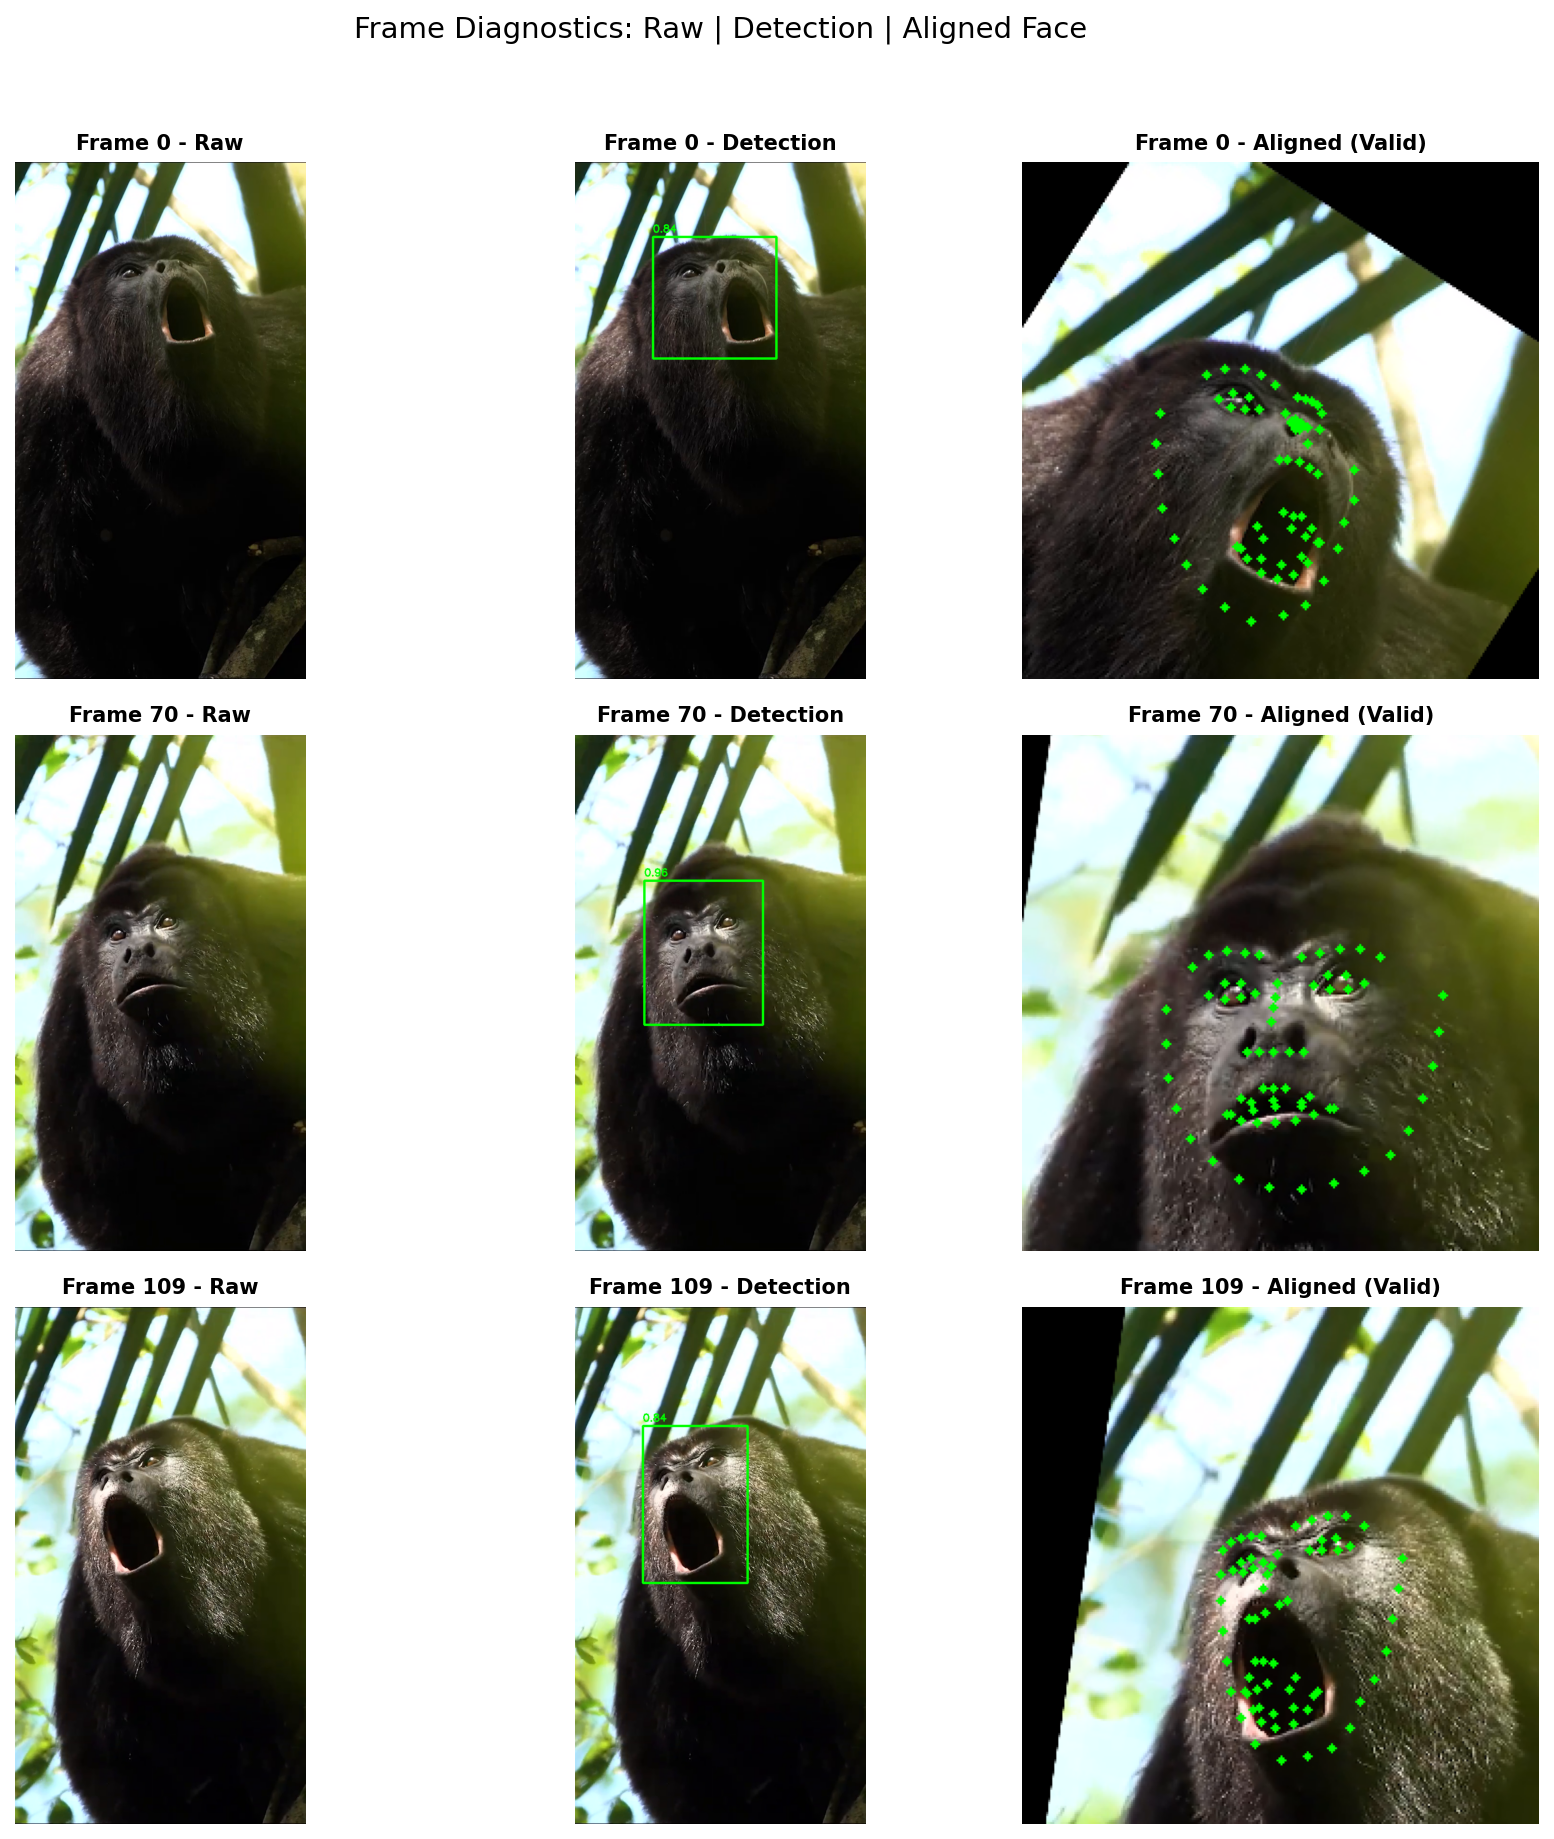

In [15]:
# Frame Diagnostics: Raw -> Detection -> Aligned Face
print("Generating frame diagnostics...")

def plot_frame_diagnostics(video_path, frame_indices, detector, pose_model, 
                           all_landmarks, valid_mask, all_transforms, output_path=None):
    """Plot diagnostic grid: Raw | Detection | Aligned Face for selected frames."""
    if not frame_indices:
        print("No frame indices provided.")
        return
    
    num_frames = len(frame_indices)
    fig, axes = plt.subplots(num_frames, 3, figsize=(7, 2.5 * num_frames), squeeze=False)
    fig.suptitle("Frame Diagnostics: Raw | Detection | Aligned Face", fontsize=14, y=1.02)
    
    diag_clip = VideoFileClip(str(video_path))
    video_fps = diag_clip.fps
    
    for i, frame_idx in enumerate(frame_indices):
        try:
            frame_time = frame_idx / video_fps
            if frame_time >= diag_clip.duration:
                raise IndexError(f"Frame {frame_idx} beyond video duration")
            
            frame_pil = diag_clip.get_frame(frame_time)
            frame_bgr = cv2.cvtColor(np.array(frame_pil), cv2.COLOR_RGB2BGR)
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        except Exception as e:
            print(f"Error reading frame {frame_idx}: {e}")
            for j in range(3):
                axes[i, j].text(0.5, 0.5, f"Error: frame {frame_idx}", ha='center', va='center')
                axes[i, j].axis('off')
            continue
        
        # Panel 1: Raw frame
        axes[i, 0].imshow(frame_rgb)
        axes[i, 0].set_title(f"Frame {frame_idx} - Raw", fontsize=10)
        axes[i, 0].axis('off')
        
        # Panel 2: Detection overlay
        img_det = frame_rgb.copy()
        det_result = inference_detector(detector, frame_bgr)
        pred_instances = det_result.pred_instances[det_result.pred_instances.scores > 0.5]
        
        if len(pred_instances) > 0:
            bbox = pred_instances.bboxes[0].cpu().numpy()
            score = pred_instances.scores[0].cpu().numpy()
            x1, y1, x2, y2 = map(int, bbox)
            cv2.rectangle(img_det, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_det, f"{score:.2f}", (x1, y1-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        axes[i, 1].imshow(img_det)
        axes[i, 1].set_title(f"Frame {frame_idx} - Detection", fontsize=10)
        axes[i, 1].axis('off')
        
        # Panel 3: Aligned face
        aligned_canvas = np.zeros((256, 256, 3), dtype=np.uint8)
        
        if frame_idx < len(valid_mask) and valid_mask[frame_idx]:
            transform_matrix = all_transforms[frame_idx]
            if transform_matrix is not None and not np.all(np.isnan(transform_matrix)):
                warped = cv2.warpAffine(frame_bgr, transform_matrix, (256, 256), borderValue=(0, 0, 0))
                aligned_canvas = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
                
                # Draw aligned landmarks
                if frame_idx < len(all_landmarks):
                    aligned_kpts = all_landmarks[frame_idx]
                    for kpt in aligned_kpts:
                        if not np.any(np.isnan(kpt)):
                            cv2.circle(aligned_canvas, (int(kpt[0]), int(kpt[1])), 2, (0, 255, 0), -1)
        
        axes[i, 2].imshow(aligned_canvas)
        status = "Valid" if (frame_idx < len(valid_mask) and valid_mask[frame_idx]) else "Invalid"
        axes[i, 2].set_title(f"Frame {frame_idx} - Aligned ({status})", fontsize=10)
        axes[i, 2].axis('off')
    
    diag_clip.close()
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.savefig(Path(output_path).with_suffix('.svg'), bbox_inches='tight')
        print(f"Saved frame diagnostics to {output_path}")
    plt.show()
    plt.close(fig)


# Select diagnostic frames (start, middle, end of valid frames)
if 'valid_mask' in dir() and valid_mask.sum() > 0:
    valid_indices = np.where(valid_mask)[0]
    n_valid = len(valid_indices)
    
    # Pick 3 frames: early, middle, late
    diag_frame_indices = [
        valid_indices[0],                    # First valid frame
        valid_indices[n_valid // 2],         # Middle valid frame
        valid_indices[min(n_valid - 1, n_valid - n_valid // 4)]  # Late valid frame
    ]
    
    print(f"Selected diagnostic frames: {diag_frame_indices}")
    
    plot_frame_diagnostics(
        VIDEO_PATH, diag_frame_indices,
        detector, pose_model,
        all_landmarks, valid_mask, all_transforms,
        output_path=str(output_base) + "_frame_diagnostics.png"
    )
else:
    print("No valid frames available for diagnostics.")

## 6. Summary and Interpretation

### What We Analyzed

1. **Mouth Aperture**: Extracted from inner lip landmarks (averaged vertical distance between points 61-67)
2. **Audio Envelope**: Maximum amplitude across frequency bands per time frame
3. **Cross-Correlation**: Tests temporal relationship between mouth and audio
4. **Predictive Model**: SVR trained to predict audio from lagged mouth aperture
5. **Frame Diagnostics**: Visual validation of landmark extraction pipeline

### Interpreting Results

**Cross-correlation peak:**
- Positive lag = mouth movement leads audio (expected for vocalizations)
- Negative lag = audio leads mouth (might indicate reactive behavior)
- Peak at ~0ms = synchronized movement and sound

**Model R² scores:**
- Original > Shuffled = mouth kinematics genuinely predict vocalization
- Original ≈ Shuffled = no meaningful coupling detected
- Higher R² = stronger vocal-motor coupling

### Generated Outputs

- `*_signals.png/svg`: Time series of mouth aperture, audio envelope, and spectrogram
- `*_xcorr.png/svg`: Cross-correlation function with peak annotation
- `*_model_performance.png/svg`: Bar chart comparing original vs shuffled R²
- `*_frame_diagnostics.png/svg`: Visual validation (Raw → Detection → Aligned)
- `*_landmarks.npz`: Cached landmark data for faster re-runs


## Citation

If you use PrimateFace in your research, please cite:

```bibtex
@article{parodi2025primateface,
  title   = {PrimateFace: A Machine Learning Resource for Automated Face Analysis in Human and Non-human Primates},
  author  = {Parodi, Felipe and Matelsky, Jordan K. and Lamacchia, Alessandro P. and Segado, Melanie and Jiang, Yaoguang and Regla-Vargas, Alejandra and Sofi, Liala and Kimock, Clare and Waller, Bridget M. and Platt, Michael L. and Kording, Konrad P.},
  journal = {bioRxiv},
  year    = {2025},
  doi     = {10.1101/2025.08.12.669927}
}
```

### References

1. [PrimateFace GitHub](https://github.com/KordingLab/PrimateFace)
2. [Librosa Documentation](https://librosa.org/doc/latest/index.html)
3. [68-point Facial Landmark Model](http://dlib.net/face_landmark_detection.py.html)